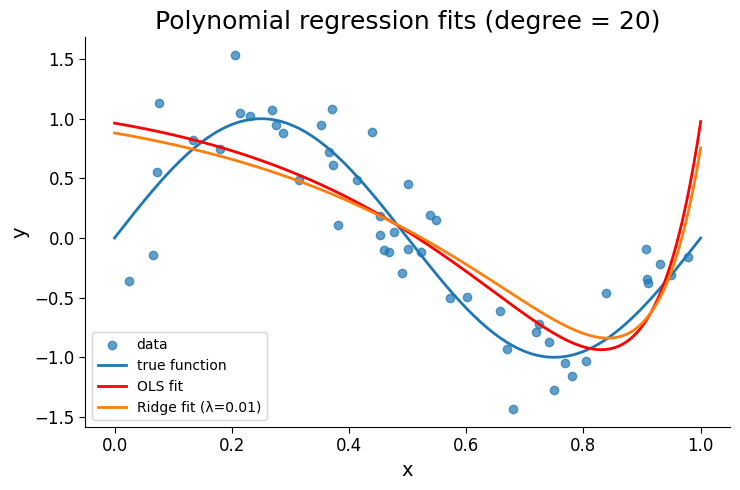

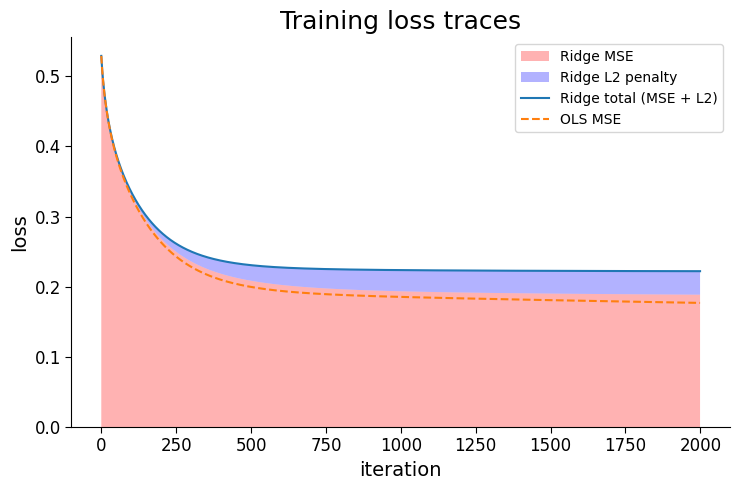

{'OLS_final_MSE': 0.17691837232743368,
 'Ridge_final_MSE': 0.1886269037413079,
 'Ridge_final_L2': 0.03349643294611311,
 'Ridge_final_total': 0.222123336687421,
 'Check_sum(MSE+L2)': 0.222123336687421}

In [25]:

# Polynomial regression with and without L2 regularization
# - Shows fitted curves
# - Shows training loss traces (MSE vs MSE+L2 with stacked breakdown)
#
# Notes:
# * Intercept is NOT penalized.
# * Uses plain gradient descent so the traces are meaningful.
# * Matplotlib only (no seaborn), one chart per figure, no manual colors.

from __future__ import annotations
from dataclasses import dataclass
from typing import Tuple, Dict
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("../clean_fig.mplstyle")

np.random.seed(7)


def make_data(n: int = 30, noise: float = 0.12) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Generate x in [0,1], true y = sin(2πx), add Gaussian noise."""
    x = np.sort(np.random.rand(n))
    y_true = np.sin(2 * np.pi * x)
    y = y_true + noise * np.random.randn(n)
    return x, y_true, y


def poly_features(x: np.ndarray, degree: int) -> np.ndarray:
    """Return Vandermonde-style polynomial features with intercept as column 0.
    We map x to [-1, 1] for numeric stability.
    """
    # x_scaled = 2 * x - 1.0
    X = np.vstack([x ** k for k in range(degree + 1)]).T
    return X


@dataclass
class GDResult:
    w: np.ndarray
    mse_trace: np.ndarray
    l2_trace: np.ndarray
    obj_trace: np.ndarray


def train_gd(
    X: np.ndarray, y: np.ndarray, lam: float, lr: float, iters: int
) -> GDResult:
    """Train polynomial regression by gradient descent with L2 (ridge) penalty.
    Intercept (w[0]) is not penalized.
    """
    n, d = X.shape
    w = np.zeros(d)
    mse_trace, l2_trace, obj_trace = [], [], []

    # mask to avoid penalizing intercept
    reg_mask = np.ones_like(w)
    reg_mask[0] = 0.0

    for _ in range(iters):
        yhat = X @ w
        resid = yhat - y
        mse = np.mean(resid ** 2)
        l2 = lam * np.sum((reg_mask * w) ** 2)
        obj = mse + l2

        mse_trace.append(mse)
        l2_trace.append(l2)
        obj_trace.append(obj)

        # gradient: d/dw (MSE) = 2/n X^T (Xw - y), d/dw (L2) = 2λ w (except intercept)
        grad = (2.0 / n) * (X.T @ resid) + 2.0 * lam * (reg_mask * w)
        w = w - lr * grad

    return GDResult(
        w=w,
        mse_trace=np.asarray(mse_trace),
        l2_trace=np.asarray(l2_trace),
        obj_trace=np.asarray(obj_trace),
    )


# ---- Simulation parameters ----
degree = 20
n = 50
noise = 0.3
iters = 2000
lr = 0.03
lam = 1e-2
# ---- Generate data and features ----
x, y_true, y = make_data(n=n, noise=noise)
X = poly_features(x, degree=degree)

# ---- Train: OLS (λ=0) and Ridge (λ>0) ----
ols = train_gd(X, y, lam=0.0, lr=lr, iters=iters)
ridge = train_gd(X, y, lam=lam, lr=lr, iters=iters)

# ---- Plot: fitted curves ----
xs = np.linspace(0, 1, 500)
Xs = poly_features(xs, degree=degree)

yhat_ols = Xs @ ols.w
yhat_ridge = Xs @ ridge.w

plt.figure(figsize=(7.5, 5))
plt.scatter(x, y, label="data", alpha=0.7)
plt.plot(xs, np.sin(2 * np.pi * xs), label="true function", linewidth=2)
plt.plot(xs, yhat_ols, label="OLS fit", color='red', linewidth=2)
plt.plot(xs, yhat_ridge, label=f"Ridge fit (λ={lam:g})", linewidth=2)
plt.title("Polynomial regression fits (degree = {})".format(degree))
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot: training loss traces ----
t = np.arange(iters)

plt.figure(figsize=(7.5, 5))
# Stacked area for Ridge: MSE and L2 components
plt.stackplot(t, ridge.mse_trace, ridge.l2_trace, labels=["Ridge MSE", "Ridge L2 penalty"], colors=["red", "blue"], alpha=0.3)
# Overlay total objective for Ridge
plt.plot(t, ridge.obj_trace, label="Ridge total (MSE + L2)", linewidth=1.5)
# Overlay OLS MSE
plt.plot(t, ols.mse_trace, label="OLS MSE", linewidth=1.5, linestyle="--")
plt.title("Training loss traces")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# ---- Print final metrics to highlight decomposition ----
final_info = {
    "OLS_final_MSE": float(ols.mse_trace[-1]),
    "Ridge_final_MSE": float(ridge.mse_trace[-1]),
    "Ridge_final_L2": float(ridge.l2_trace[-1]),
    "Ridge_final_total": float(ridge.obj_trace[-1]),
    "Check_sum(MSE+L2)": float(ridge.mse_trace[-1] + ridge.l2_trace[-1]),
}
final_info

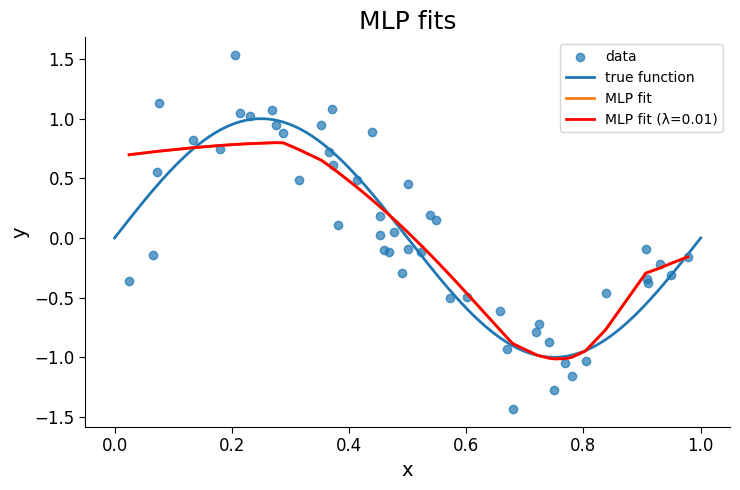

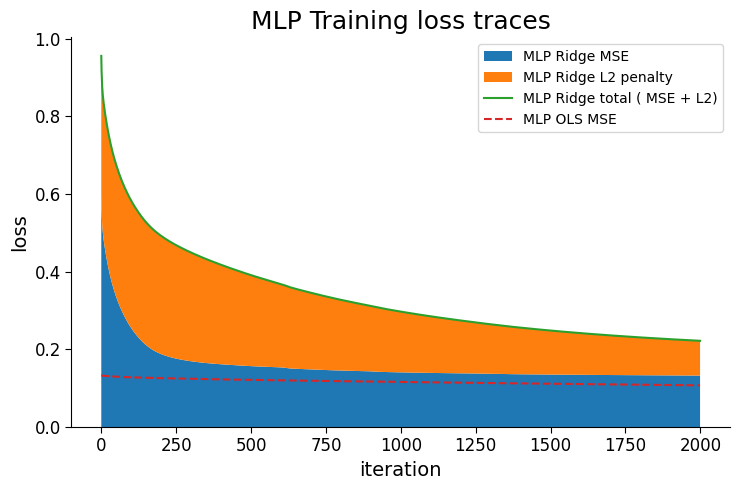

In [32]:
# Train an MLP on the same data for comparison
import torch
import torch.nn as nn
import torch.optim as optim
torch.manual_seed(7)
import torch.nn.functional as F

# --- IGNORE ---
class MLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# training loop tracking both empirical loss and L2 penalty
def train_mlp(
    model: nn.Module,
    X: torch.Tensor,
    y: torch.Tensor,
    lam: float,
    lr: float,
    iters: int,
) -> Tuple[nn.Module, np.ndarray, np.ndarray, np.ndarray]:
    mse_trace, l2_trace, obj_trace = [], [], []
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for _ in range(iters):
        model.train()
        optimizer.zero_grad()
        yhat = model(X).squeeze()
        mse = criterion(yhat, y)
        l2 = lam * sum((p ** 2).sum() for p in model.parameters())
        obj = mse + l2

        mse_trace.append(mse.item())
        l2_trace.append(l2.item())
        obj_trace.append(obj.item())
        obj.backward()
        optimizer.step()
    return model, np.asarray(mse_trace), np.asarray(l2_trace), np.asarray(obj_trace)


# ---- Train MLP ----
# X_torch = torch.tensor(x, dtype=torch.float32).unsqueeze(1)
X_torch = torch.tensor(X, dtype=torch.float32)
y_torch = torch.tensor(y, dtype=torch.float32)
mlp = MLP(input_dim=degree+1, hidden_dim=100, output_dim=1)
mlp_reg, mlp_reg_mse_trace, mlp_reg_l2_trace, mlp_reg_obj_trace = train_mlp(
    mlp, X_torch, y_torch, lam=lam, lr=0.03, iters=iters
)
# without regularization now
mlp, mlp_mse_trace, mlp_l2_trace, mlp_obj_trace = train_mlp(
    mlp, X_torch, y_torch, lam=0.0, lr=0.03, iters=iters
)


# ---- Plot: MLP fitted curve ----
yhat_mlp = mlp(X_torch).detach().numpy().squeeze()
yhat_mlp_reg = mlp_reg(X_torch).detach().numpy().squeeze()
plt.figure(figsize=(7.5, 5))
plt.scatter(x, y, label="data", alpha=0.7)
plt.plot(xs, np.sin(2 * np.pi * xs), label="true function", linewidth=2)
plt.plot(x, yhat_mlp, label="MLP fit", linewidth=2)
plt.plot(x, yhat_mlp_reg, label=f"MLP fit (λ={lam:g})", color='red', linewidth=2)
plt.title("MLP fits")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot: MLP training loss traces ----
t = np.arange(iters)
plt.figure(figsize=(7.5, 5))
# Stacked area for Ridge: MSE and L2 components
plt.stackplot(t, mlp_reg_mse_trace, mlp_reg_l2_trace, labels=["MLP Ridge MSE", "MLP Ridge L2 penalty"])
# Overlay total objective for Ridge
plt.plot(t, mlp_reg_obj_trace, label="MLP Ridge total ( MSE + L2)", linewidth=1.5)
# Overlay OLS MSE
plt.plot(t, mlp_mse_trace, label="MLP OLS MSE", linewidth=1.5, linestyle="--")
plt.title("MLP Training loss traces")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

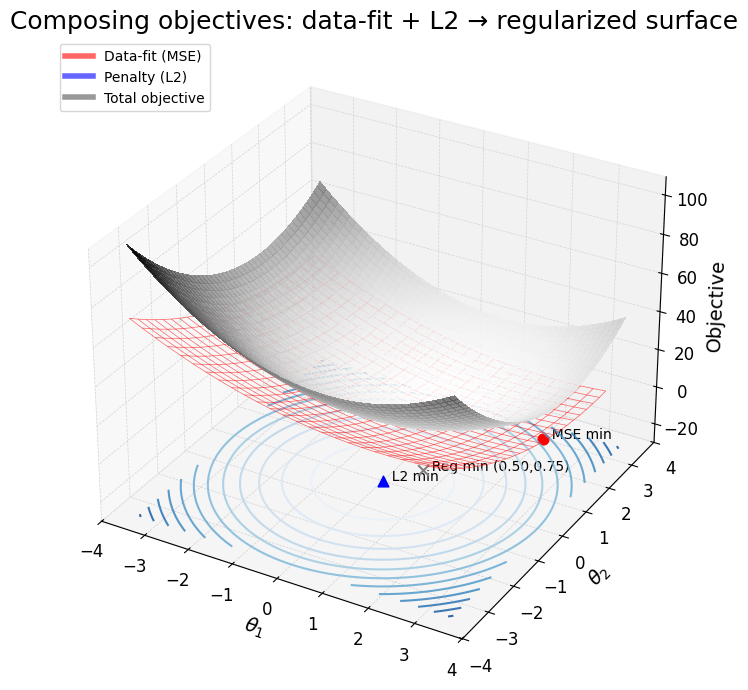

In [ ]:
# Generalizable 3D visualization with modular objectives (using callables/partials)
# - Components are functions w -> scalar; we pass them in a list and visualize:
#   * total surface = sum of components
#   * wireframe for the "data-fit" component (first in list)
#   * contour & projected contour for the "penalty" component (second in list)
# - Intercepts not relevant here; just a 2D parameter space demo.
#
# One figure; matplotlib only; no explicit colors.

from __future__ import annotations
from typing import Callable, Tuple, List, Dict
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from functools import partial

PLOT_FLOOR = -30.0

Vec2 = Tuple[float, float]
Grid = Tuple[np.ndarray, np.ndarray]


def eval_on_grid(
    component: Callable[[np.ndarray, np.ndarray], np.ndarray],
    W1: np.ndarray,
    W2: np.ndarray,
) -> np.ndarray:
    return component(W1, W2)


# --- Example component factories ------------------------------------------------


def quad_mse(
    center: Vec2 = (1.0, 1.0), scale: float = 0.5
) -> Callable[[np.ndarray, np.ndarray], np.ndarray]:
    cx, cy = center

    def f(W1: np.ndarray, W2: np.ndarray) -> np.ndarray:
        return scale * ((W1 - cx) ** 2 + (W2 - cy) ** 2)

    return f


def l2_penalty(lam: float = 0.3) -> Callable[[np.ndarray, np.ndarray], np.ndarray]:
    def f(W1: np.ndarray, W2: np.ndarray) -> np.ndarray:
        return lam * (W1**2 + W2**2)

    return f


def ridge_minimizer_2d(
    lam: float, mse_scale: float = 0.5, mse_center: Vec2 = (1.0, 1.0)
) -> Vec2:
    # Minimizer for mse_scale*((w-c)^2) + lam*||w||^2 with isotropic pieces:
    # (mse_scale + lam*2) w = mse_scale * c  ->  w* = alpha * c, alpha = mse_scale / (mse_scale + 2*lam)
    cx, cy = mse_center
    alpha = mse_scale / (mse_scale + 2.0 * lam)
    return alpha * cx, alpha * cy


# --- Compose components ---------------------------------------------------------

mse_center = (2.0, 3.0)
mse_scale = 1.0
lam = 1.5

components: List[Callable[[np.ndarray, np.ndarray], np.ndarray]] = [
    quad_mse(center=mse_center, scale=mse_scale),  # data-fit
    l2_penalty(lam=lam),  # penalty
]

# Grid
w1 = np.linspace(-3.5, 3.5, 200)
w2 = np.linspace(-3.5, 3.5, 200)
W1, W2 = np.meshgrid(w1, w2)

# Evaluate
Zs = [eval_on_grid(comp, W1, W2) for comp in components]
Z_total = np.sum(Zs, axis=0)

# Optima
w_mse = mse_center
w_l2 = (0.0, 0.0)
w_ridge = ridge_minimizer_2d(lam=lam, mse_scale=mse_scale, mse_center=mse_center)


def obj_at(w: Vec2) -> float:
    x, y = w
    return mse_scale * ((x - mse_center[0]) ** 2 + (y - mse_center[1]) ** 2) + lam * (
        x**2 + y**2
    )


# --- Plot ----------------------------------------------------------------------
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Total surface, no colors
surf = ax.plot_surface(
    W1, W2, Z_total, linewidth=0, antialiased=False, alpha=0.8, cmap="Greys"
)

# Data-fit wireframe (first component)
ax.plot_wireframe(
    W1[::8, ::8], W2[::8, ::8], Zs[0][::8, ::8], linewidth=0.5, alpha=0.6, color="red"
)

# Penalty contours (second component) in 3D and projected to the floor
# ax.contour3D(W1, W2, Zs[1], levels=12, alpha=0.8, zorder=-1)
ax.contour(
    W1,
    W2,
    Zs[1],
    zdir="z",
    offset=PLOT_FLOOR,
    levels=12,
    alpha=0.8,
    zorder=-1,
    cmap="Blues",
)


# Points
def scatter_point(x: float, y: float, z: float, label: str, **kwargs) -> None:
    ax.scatter([x], [y], [z], s=60, **kwargs)
    ax.text(x, y, z, "  " + label)


scatter_point(*w_mse, PLOT_FLOOR, "MSE min", marker="o", color="red", zorder=5)
scatter_point(*w_l2, PLOT_FLOOR, "L2 min", marker="^", color="blue", zorder=5)
scatter_point(*w_ridge, PLOT_FLOOR, f"Reg min ({w_ridge[0]:.2f},{w_ridge[1]:.2f})", marker="x", color="gray", zorder=5)

ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_2$")
ax.set_zlabel("Objective")
ax.set_title("Composing objectives: data-fit + L2 → regularized surface")
ax.set_zlim(PLOT_FLOOR, float(np.max(Z_total)))

# Lightweight legend via proxy artists
from matplotlib.lines import Line2D

proxies = [
    Line2D([0], [0], color="red", lw=4, label="Data-fit (MSE)", alpha=0.6),
    Line2D([0], [0], color="blue", lw=4, label="Penalty (L2)", alpha=0.6),
    Line2D([0], [0], color="grey", lw=4, label="Total objective", alpha=0.8),
]
ax.legend(handles=proxies, loc="upper left")


fig.tight_layout()
plt.savefig("tradeoff-vis.png", dpi=300)

